# Model 1A, Experiment 04: Causal 30-Minute Departure Backlog

This experiment keeps the raw Experiment 01 schedule, airline, destination, planned-demand, and weather baseline and adds operational backlog information reconstructed at each flight's scheduled departure cutoff. The target is `DepDel15`.

For a sample cutoff `DATE`, backlog members must have been scheduled in `[DATE - 30 minutes, DATE)`. Delay summaries use only members that pushed back strictly before the cutoff. Earlier-scheduled flights that have not pushed back contribute to pending count but never contribute their eventual delay value. Flights at the sample timestamp and the sample flight itself are excluded by construction.

Within five expanding 2019 folds, the search compares a compact, nonduplicative three-feature backlog manifest with all eight generated backlog fields. It also selects regularization strength, L1 versus L2, and class weighting. The winner is refitted on all 2019 rows and evaluated once on 2023. The 2024 dataset is not loaded.

In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 30

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load and validate the backlog-enhanced 2019 and 2023 departure data

The path lookup supports the project root and the `models` directory. Only the separately generated `backlog_w30` datasets are loaded; 2024 remains locked.

In [3]:
def find_project_root(start: Path, airport: str, years, window_minutes: int) -> Path:
    relative_paths = [
        Path("data/features")
        / f"{airport}_{year}_departures_backlog_w{window_minutes}.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).exists() for path in relative_paths):
            return candidate
    raise FileNotFoundError(f"Could not locate all required files: {relative_paths}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
    BACKLOG_WINDOW_MINUTES,
)
TRAIN_DATA_PATH = (
    PROJECT_ROOT / "data/features"
    / f"{AIRPORT}_{TRAIN_YEAR}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
)
VALIDATION_DATA_PATH = (
    PROJECT_ROOT / "data/features"
    / f"{AIRPORT}_{VALIDATION_YEAR}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
)

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)

print(f"Training source: {TRAIN_DATA_PATH}")
print(f"Training rows: {len(train_df):,}; columns: {train_df.shape[1]:,}")
print(f"Validation source: {VALIDATION_DATA_PATH}")
print(f"Validation rows: {len(validation_df):,}; columns: {validation_df.shape[1]:,}")

Training source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2019_departures_backlog_w30.csv
Training rows: 107,430; columns: 114
Validation source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2023_departures_backlog_w30.csv
Validation rows: 109,983; columns: 114


In [4]:
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT",
    f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT",
    f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT",
    f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    missing = sorted(required - set(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"

    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="coerce")
    cutoff = pd.to_datetime(frame["DATE"], errors="coerce")
    assert frame["FlightDate"].notna().all(), f"{partition} invalid FlightDate"
    assert cutoff.notna().all(), f"{partition} invalid DATE"
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Origin"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})

    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(frame[column], errors="coerce")
        for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.notna().all() and completed.notna().all() and pending.notna().all()
    assert delayed_count.notna().all()
    assert scheduled.eq(completed + pending).all()
    assert delayed_count.le(completed).all()
    same_cutoff_variants = (
        frame.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False)
        .to_numpy()
        .max(initial=0)
    )
    assert same_cutoff_variants <= 1

    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
        "mean_pending": pending.mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate,mean_pending
partition,,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107430,20168,0.1877,1.7030
external validation,2023,2023-01-01,2023-12-31,365,109983,25995,0.2364,2.0379


## Prediction-time feature manifests

Both candidates retain the exact 20-field raw Experiment 01 baseline. The compact backlog variant adds pending count, completed count, and mean signed delay. The full variant makes all eight generated fields available and relies on the classifier's regularization to suppress redundant terms. Comparing these predefined manifests inside the 2019 folds is feature selection; 2023 does not choose between them.

In [5]:
CATEGORICAL_FEATURES = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Dest",
]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES",
    "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES",
    "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES",
    "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature",
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyWindSpeed",
]
BACKLOG_VARIANTS = {
    "compact": COMPACT_BACKLOG_FEATURES,
    "full": FULL_BACKLOG_FEATURES,
}
ALL_MODEL_FEATURES = CATEGORICAL_FEATURES + BASE_NUMERIC_FEATURES + FULL_BACKLOG_FEATURES
REQUIRED_COLUMNS = ["FlightDate", "Origin", TARGET, *ALL_MODEL_FEATURES]

for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    assert not missing, f"{partition} missing model columns: {missing}"

FORBIDDEN_PREDICTORS = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes",
    "DepartureDelayGroups", "TaxiOut", "WheelsOff",
    "ArrDel15", "ArrivalDelayGroups", "Tail_Number",
}
assert not FORBIDDEN_PREDICTORS.intersection(ALL_MODEL_FEATURES)

pd.DataFrame({
    name: {
        "raw_baseline_fields": len(CATEGORICAL_FEATURES) + len(BASE_NUMERIC_FEATURES),
        "backlog_fields": len(backlog_features),
        "total_fields": len(CATEGORICAL_FEATURES) + len(BASE_NUMERIC_FEATURES) + len(backlog_features),
    }
    for name, backlog_features in BACKLOG_VARIANTS.items()
}).T

,raw_baseline_fields,backlog_fields,total_fields
compact,20,3,23
full,20,8,28


## Missingness and expanding-day partitions

No row is dropped for missing predictors. Imputation, missingness indicators, category encoding, scaling, manifest choice, and classifier settings are learned using only the 2019 training folds. Complete calendar days remain together.

In [6]:
def prepare_model_frame(source_frame: pd.DataFrame) -> pd.DataFrame:
    model_frame = source_frame[REQUIRED_COLUMNS].copy()
    model_frame = model_frame.sort_values(
        ["FlightDate", "CRSDepTime"], kind="stable"
    ).reset_index(drop=True)
    model_frame[TARGET] = model_frame[TARGET].astype(int)
    for column in CATEGORICAL_FEATURES:
        model_frame[column] = model_frame[column].astype(object)
    for column in BASE_NUMERIC_FEATURES + FULL_BACKLOG_FEATURES:
        model_frame[column] = pd.to_numeric(model_frame[column], errors="coerce")
    return model_frame


def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized_dates = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized_dates)))
    if len(unique_days) < n_splits + 1:
        raise ValueError("Not enough unique days for the requested temporal folds")
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []
    for fold_number in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold_number])
        validation_days = day_blocks[fold_number]
        train_indices = np.flatnonzero(np.isin(normalized_dates, train_days))
        validation_indices = np.flatnonzero(np.isin(normalized_dates, validation_days))
        assert train_days.max() < validation_days.min()
        splits.append((train_indices, validation_indices))
        rows.append({
            "fold": fold_number,
            "train_start": pd.Timestamp(train_days.min()).date(),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(validation_days.min()).date(),
            "validation_end": pd.Timestamp(validation_days.max()).date(),
            "train_rows": len(train_indices),
            "validation_rows": len(validation_indices),
            "train_delay_rate": targets.iloc[train_indices].mean(),
            "validation_delay_rate": targets.iloc[validation_indices].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train = train_model_df[ALL_MODEL_FEATURES].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
X_validation = validation_model_df[ALL_MODEL_FEATURES].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
assert training_dates.max() < validation_dates.min()

temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates, y_train, N_TIME_SPLITS
)
missing_summary = pd.DataFrame({
    "training_missing": X_train.isna().sum(),
    "validation_missing": X_validation.isna().sum(),
})
display(missing_summary[missing_summary.sum(axis=1).gt(0)])
fold_summary

,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
HourlyDewPointTemperature,46,0
HourlyPrecipitation,22,21
HourlyVisibility,0,28
BACKLOG_W30_DELAY_RATE,2214,1784
BACKLOG_W30_MEAN_DEP_DELAY,2214,1784
BACKLOG_W30_MEAN_DEP_DELAY_MINUTES,2214,1784


,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_delay_rate,validation_delay_rate
fold,,,,,,,,
1,2019-01-01,2019-03-02,2019-03-03,2019-05-02,17737,18776,0.1892,0.1674
2,2019-01-01,2019-05-02,2019-05-03,2019-07-02,36513,18150,0.1780,0.2072
3,2019-01-01,2019-07-02,2019-07-03,2019-09-01,54663,17758,0.1877,0.2577
4,2019-01-01,2019-09-01,2019-09-02,2019-11-01,72421,17686,0.2048,0.1384
5,2019-01-01,2019-11-01,2019-11-02,2019-12-31,90107,17323,0.1918,0.1666


## Training-only manifest and logistic-regression search

Each backlog manifest receives the same 16 logistic configurations. Numeric median imputation with missingness indicators, scaling, category imputation, and one-hot encoding are inside each pipeline. The winner is the candidate with the greatest mean temporal-validation average precision. L1 candidates perform embedded coefficient selection; L2 remains available if distributed evidence works better.

In [7]:
def make_logistic_search(backlog_features):
    numeric_features = BASE_NUMERIC_FEATURES + list(backlog_features)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    preprocessor = ColumnTransformer([
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ("numeric", numeric_pipeline, numeric_features),
    ], remainder="drop")
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            solver="liblinear", max_iter=5_000, random_state=RANDOM_STATE
        )),
    ])
    parameter_grid = {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__l1_ratio": [1.0, 0.0],
        "classifier__class_weight": [None, "balanced"],
    }
    scoring = {
        "average_precision": "average_precision",
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": "recall",
        "f1": "f1",
        "mcc": make_scorer(matthews_corrcoef),
        "neg_brier": "neg_brier_score",
    }
    search = GridSearchCV(
        pipeline, parameter_grid, scoring=scoring, refit="average_precision",
        cv=temporal_splits, n_jobs=N_JOBS, pre_dispatch=N_JOBS, verbose=1,
        return_train_score=False, error_score="raise",
    )
    return search, numeric_features, len(list(ParameterGrid(parameter_grid)))


variant_searches = {}
variant_numeric_features = {}
search_rows = []
cv_result_frames = []
total_search_start = perf_counter()

for variant_name, backlog_features in BACKLOG_VARIANTS.items():
    search, numeric_features, candidate_count = make_logistic_search(backlog_features)
    variant_features = CATEGORICAL_FEATURES + numeric_features
    variant_start = perf_counter()
    search.fit(X_train[variant_features], y_train)
    variant_seconds = perf_counter() - variant_start
    variant_searches[variant_name] = search
    variant_numeric_features[variant_name] = numeric_features
    results = pd.DataFrame(search.cv_results_)
    results["backlog_variant"] = variant_name
    cv_result_frames.append(results)
    search_rows.append({
        "backlog_variant": variant_name,
        "backlog_fields": len(backlog_features),
        "candidates": candidate_count,
        "temporal_fits": candidate_count * len(temporal_splits),
        "best_mean_cv_ap": search.best_score_,
        "seconds": variant_seconds,
    })

search_seconds = perf_counter() - total_search_start
search_summary = pd.DataFrame(search_rows).set_index("backlog_variant")
search_summary

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 16 candidates, totalling 80 fits


/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,backlog_fields,candidates,temporal_fits,best_mean_cv_ap,seconds
backlog_variant,,,,,
compact,3,16,80,0.3852,43.6785
full,8,16,80,0.3852,55.3274


In [8]:
selected_variant = search_summary["best_mean_cv_ap"].idxmax()
selected_search = variant_searches[selected_variant]
best_logistic_pipeline = selected_search.best_estimator_
selected_backlog_features = BACKLOG_VARIANTS[selected_variant]
selected_numeric_features = variant_numeric_features[selected_variant]
selected_feature_columns = CATEGORICAL_FEATURES + selected_numeric_features

cv_results = pd.concat(cv_result_frames, ignore_index=True)
cv_results["classifier_penalty"] = cv_results["param_classifier__l1_ratio"].map(
    {1.0: "l1", 0.0: "l2"}
)
result_columns = [
    "backlog_variant", "mean_test_average_precision",
    "std_test_average_precision", "mean_test_roc_auc",
    "mean_test_balanced_accuracy", "mean_test_precision",
    "mean_test_recall", "mean_test_f1", "mean_test_mcc",
    "mean_test_neg_brier", "param_classifier__C",
    "classifier_penalty", "param_classifier__class_weight",
]
display(cv_results.sort_values("mean_test_average_precision", ascending=False)[result_columns].head(12))
print(f"Total search and refit time: {search_seconds:,.1f} seconds")
print(f"Selected backlog variant: {selected_variant}")
print(f"Selected mean temporal-validation AP: {selected_search.best_score_:.4f}")
display(pd.Series(selected_search.best_params_, name="value").to_frame())

,backlog_variant,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_mcc,mean_test_neg_brier,param_classifier__C,classifier_penalty,param_classifier__class_weight
0,compact,0.3852,0.0675,0.7035,0.5324,0.6333,0.0751,0.1325,0.1674,-0.1365,0.0100,l1,NaN
16,full,0.3852,0.0675,0.7035,0.5324,0.6333,0.0751,0.1325,0.1674,-0.1365,0.0100,l1,NaN
4,compact,0.3826,0.0677,0.7029,0.5364,0.6262,0.0847,0.1474,0.1785,-0.1386,0.1000,l1,NaN
2,compact,0.3825,0.0653,0.7043,0.6453,0.3151,0.5785,0.4064,0.2385,-0.2050,0.0100,l1,balanced
18,full,0.3824,0.0654,0.7042,0.6449,0.3151,0.5773,0.4061,0.2381,-0.2049,0.0100,l1,balanced
1,compact,0.3823,0.0697,0.7025,0.5426,0.6034,0.1002,0.1708,0.1900,-0.1377,0.0100,l2,NaN
17,full,0.3820,0.0699,0.7024,0.5428,0.6051,0.1008,0.1716,0.1909,-0.1377,0.0100,l2,NaN
20,full,0.3813,0.0688,0.7020,0.5354,0.6263,0.0824,0.1441,0.1763,-0.1386,0.1000,l1,NaN
5,compact,0.3781,0.0732,0.6996,0.5428,0.5926,0.1024,0.1717,0.1862,-0.1385,0.1000,l2,NaN
21,full,0.3778,0.0735,0.6995,0.5424,0.5911,0.1016,0.1704,0.1848,-0.1386,0.1000,l2,NaN


Total search and refit time: 99.0 seconds
Selected backlog variant: compact
Selected mean temporal-validation AP: 0.3852


,value
classifier__C,0.0100
classifier__class_weight,NaN
classifier__l1_ratio,1.0000


In [9]:
encoded_feature_names = (
    best_logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
)
classifier = best_logistic_pipeline.named_steps["classifier"]
nonzero_mask = ~np.isclose(classifier.coef_[0], 0.0)
prepared_feature_summary = pd.Series({
    "selected_backlog_variant": selected_variant,
    "source_fields": len(selected_feature_columns),
    "backlog_fields": len(selected_backlog_features),
    "prepared_columns": len(encoded_feature_names),
    "nonzero_coefficients": int(nonzero_mask.sum()),
    "zero_coefficients": int((~nonzero_mask).sum()),
}, name="value")
prepared_feature_summary.to_frame()

,value
selected_backlog_variant,compact
source_fields,23
backlog_fields,3
prepared_columns,103
nonzero_coefficients,40
zero_coefficients,63


## Select the operating threshold from 2019 only

The selected pipeline is cloned into each temporal fold. Thresholds from 0.05 through 0.50 are ranked by F1 on held-out 2019 probabilities, with balanced accuracy and precision as tie-breakers.

Threshold-selection rows: 89,693
Training-only selected threshold: 0.21


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc
16,0.2100,0.7179,0.6491,0.3405,0.5389,0.4173,0.2547
17,0.2200,0.7350,0.6465,0.3546,0.5051,0.4167,0.2586
15,0.2000,0.6980,0.6505,0.3264,0.5746,0.4163,0.2499
18,0.2300,0.7497,0.6435,0.3692,0.4735,0.4149,0.2620
14,0.1900,0.6754,0.6502,0.3125,0.6099,0.4133,0.2434
19,0.2400,0.7626,0.6402,0.3846,0.4443,0.4123,0.2656
20,0.2500,0.7738,0.6369,0.4008,0.4180,0.4093,0.2695
13,0.1800,0.6506,0.6482,0.2993,0.6444,0.4087,0.2357
12,0.1700,0.6239,0.6457,0.2874,0.6806,0.4042,0.2289
21,0.2600,0.7825,0.6323,0.4151,0.3919,0.4032,0.2705


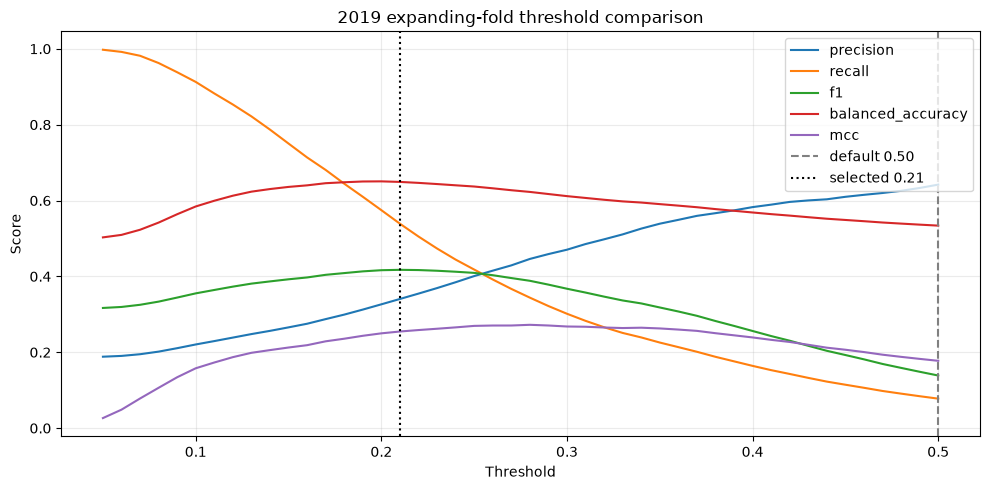

In [10]:
oof_probabilities = np.full(len(y_train), np.nan)
for train_indices, validation_indices in temporal_splits:
    fold_model = clone(best_logistic_pipeline)
    fold_model.fit(
        X_train.iloc[train_indices][selected_feature_columns],
        y_train.iloc[train_indices],
    )
    oof_probabilities[validation_indices] = fold_model.predict_proba(
        X_train.iloc[validation_indices][selected_feature_columns]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
threshold_rows = []
for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2):
    predictions = (oof_p >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(oof_y, predictions),
        "balanced_accuracy": balanced_accuracy_score(oof_y, predictions),
        "precision": precision_score(oof_y, predictions, zero_division=0),
        "recall": recall_score(oof_y, predictions, zero_division=0),
        "f1": f1_score(oof_y, predictions, zero_division=0),
        "mcc": matthews_corrcoef(oof_y, predictions),
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"], ascending=False
).iloc[0]
selected_threshold = float(best_threshold_row["threshold"])
print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
display(threshold_results.sort_values("f1", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["precision", "recall", "f1", "balanced_accuracy", "mcc"]:
    ax.plot(threshold_results["threshold"], threshold_results[metric], label=metric)
ax.axvline(0.50, color="gray", linestyle="--", label="default 0.50")
ax.axvline(selected_threshold, color="black", linestyle=":", label=f"selected {selected_threshold:.2f}")
ax.set(title="2019 expanding-fold threshold comparison", xlabel="Threshold", ylabel="Score")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Evaluate the untouched 2023 external-validation partition

The winning estimator was refitted on all 2019 rows by its grid search. The 2023 probabilities are evaluated at both 0.50 and the threshold selected above.

In [11]:
def evaluate_probabilities(y_true, probabilities, model_name, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


prediction_start = perf_counter()
validation_probabilities = best_logistic_pipeline.predict_proba(
    X_validation[selected_feature_columns]
)[:, 1]
prediction_seconds = perf_counter() - prediction_start
dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train[selected_feature_columns], y_train)
dummy_probabilities = dummy_model.predict_proba(
    X_validation[selected_feature_columns]
)[:, 1]
evaluation_results = pd.DataFrame([
    evaluate_probabilities(y_validation, dummy_probabilities, "Dummy (2019 prior)", 0.50),
    evaluate_probabilities(y_validation, validation_probabilities, "Logistic (default)", 0.50),
    evaluate_probabilities(
        y_validation, validation_probabilities, "Logistic (training-selected)", selected_threshold
    ),
]).set_index("model")
print(f"2023 probability prediction time: {prediction_seconds:,.3f} seconds")
evaluation_results

2023 probability prediction time: 0.102 seconds


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Dummy (2019 prior),0.5000,0.7636,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.2364,0.1829
Logistic (default),0.5000,0.7714,0.5371,0.6075,0.0926,0.1608,0.1689,0.6903,0.4184,0.1653
Logistic (training-selected),0.2100,0.6587,0.6355,0.3635,0.5916,0.4503,0.2367,0.6903,0.4184,0.1653


In [12]:
ranking_row = evaluation_results.loc["Logistic (default)"]
default_row = evaluation_results.loc["Logistic (default)"]
selected_row = evaluation_results.loc["Logistic (training-selected)"]
appendix_d_summary = pd.Series({
    "selected_backlog_variant": selected_variant,
    "backlog_fields": len(selected_backlog_features),
    "source_fields": len(selected_feature_columns),
    "prepared_columns": len(encoded_feature_names),
    "nonzero_coefficients": int(nonzero_mask.sum()),
    "classifier_C": selected_search.best_params_["classifier__C"],
    "classifier_penalty": (
        "l1" if selected_search.best_params_["classifier__l1_ratio"] == 1.0 else "l2"
    ),
    "class_weight": str(selected_search.best_params_["classifier__class_weight"]),
    "training_cv_ap": selected_search.best_score_,
    "validation_prevalence": y_validation.mean(),
    "validation_ap": ranking_row["average_precision"],
    "validation_roc_auc": ranking_row["roc_auc"],
    "validation_brier": ranking_row["brier_score"],
    "selected_threshold": selected_threshold,
    "default_accuracy": default_row["accuracy"],
    "default_balanced_accuracy": default_row["balanced_accuracy"],
    "default_precision": default_row["precision"],
    "default_recall": default_row["recall"],
    "default_f1": default_row["f1"],
    "default_mcc": default_row["mcc"],
    "selected_accuracy": selected_row["accuracy"],
    "selected_balanced_accuracy": selected_row["balanced_accuracy"],
    "selected_precision": selected_row["precision"],
    "selected_recall": selected_row["recall"],
    "selected_f1": selected_row["f1"],
    "selected_mcc": selected_row["mcc"],
    "search_seconds": search_seconds,
    "prediction_seconds": prediction_seconds,
}, name="Experiment 04 Appendix E values")
appendix_d_summary.to_frame()

,Experiment 04 Appendix E values
selected_backlog_variant,compact
backlog_fields,3
source_fields,23
prepared_columns,103
nonzero_coefficients,40
classifier_C,0.0100
classifier_penalty,l1
class_weight,None
training_cv_ap,0.3852
validation_prevalence,0.2364


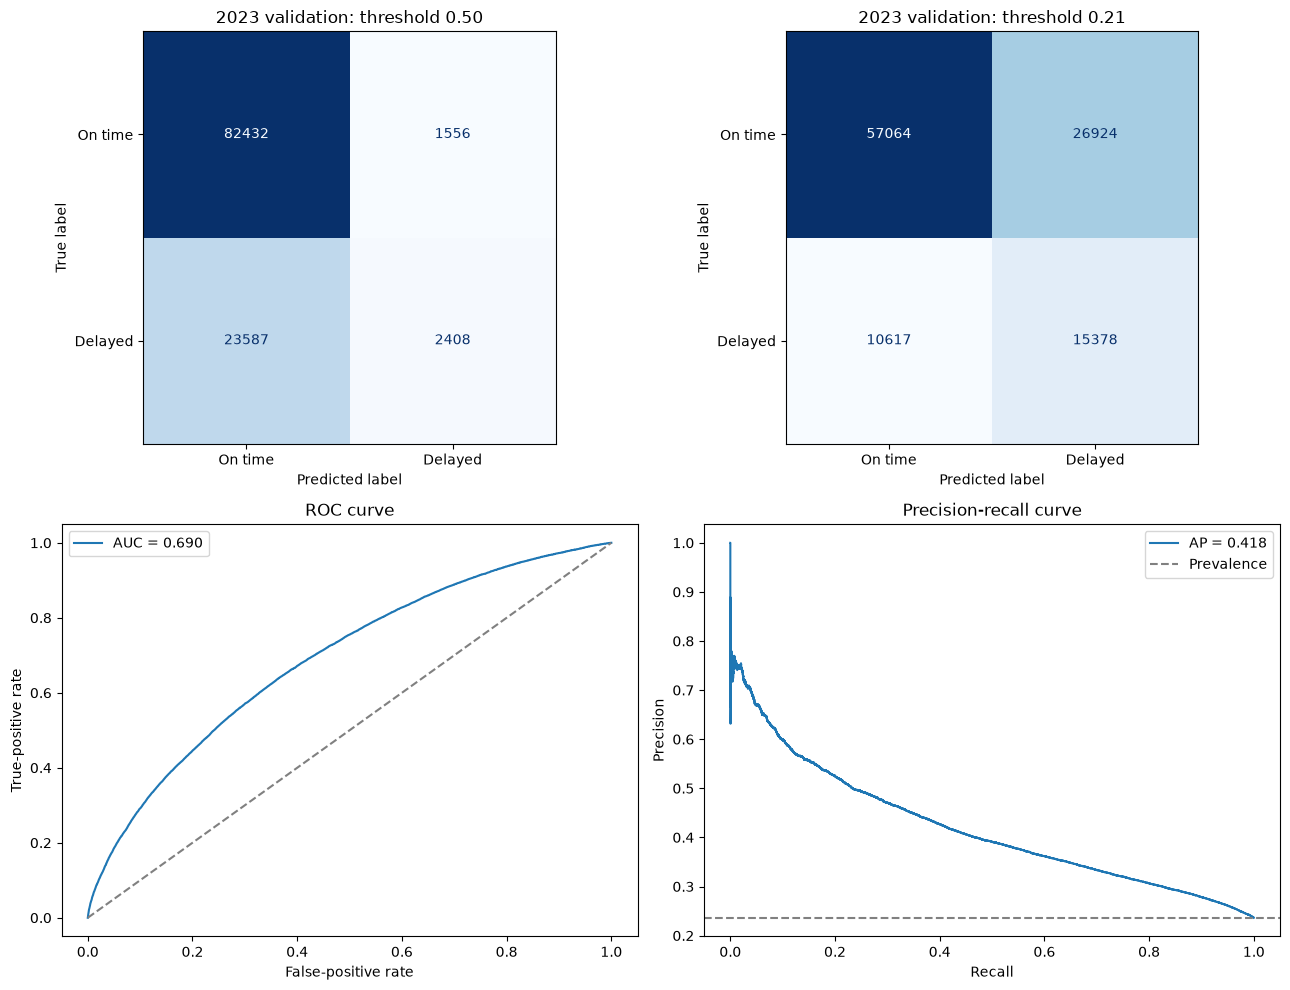

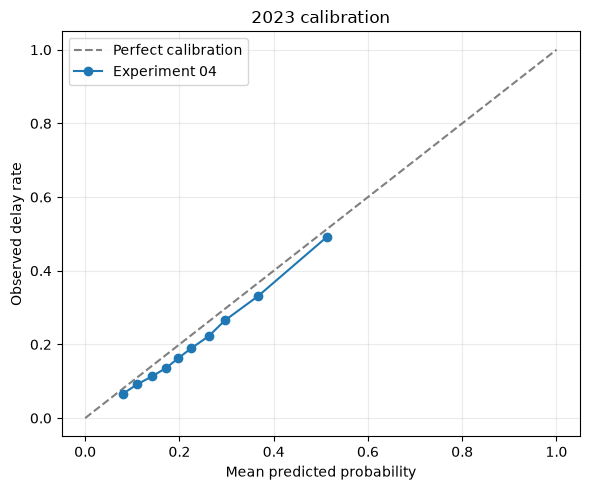

In [13]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
calibration_predicted, calibration_observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile"
)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation, default_predictions, display_labels=["On time", "Delayed"],
    cmap="Blues", colorbar=False, ax=axes[0, 0]
)
axes[0, 0].set_title("2023 validation: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation, selected_predictions, display_labels=["On time", "Delayed"],
    cmap="Blues", colorbar=False, ax=axes[0, 1]
)
axes[0, 1].set_title(f"2023 validation: threshold {selected_threshold:.2f}")
axes[1, 0].plot(false_positive_rate, true_positive_rate, label=f"AUC = {ranking_row['roc_auc']:.3f}")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curve")
axes[1, 0].legend()
axes[1, 1].plot(curve_recall, curve_precision, label=f"AP = {ranking_row['average_precision']:.3f}")
axes[1, 1].axhline(y_validation.mean(), linestyle="--", color="gray", label="Prevalence")
axes[1, 1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
axes[1, 1].legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(calibration_predicted, calibration_observed, marker="o", label="Experiment 04")
ax.set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="2023 calibration")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect standardized coefficients

Coefficient signs and magnitudes describe associations within this encoded design and do not establish causes. Correlated backlog identities can exchange coefficient weight; the training-fold manifest comparison is more important than any one redundant coefficient.

In [14]:
coefficient_series = pd.Series(
    classifier.coef_[0], index=encoded_feature_names, name="coefficient"
)
coefficient_table = (
    coefficient_series.rename_axis("feature").reset_index()
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
display(coefficient_table.head(20))
backlog_coefficients = coefficient_table[
    coefficient_table["feature"].str.contains(BACKLOG_PREFIX, regex=False)
]
backlog_coefficients

,feature,coefficient,abs_coefficient
95,numeric__BACKLOG_W30_PENDING_COUNT,0.3339,0.3339
7,categorical__Month_8,0.2269,0.2269
79,numeric__CRSDepTime,0.2261,0.2261
10,categorical__Month_11,-0.2198,0.2198
52,categorical__Dest_LAX,-0.2160,0.2160
9,categorical__Month_10,-0.2000,0.2000
96,numeric__BACKLOG_W30_COMPLETED_COUNT,-0.1898,0.1898
97,numeric__BACKLOG_W30_MEAN_DEP_DELAY,0.1675,0.1675
6,categorical__Month_7,0.1595,0.1595
20,categorical__Reporting_Airline_AA,-0.1526,0.1526


,feature,coefficient,abs_coefficient
95,numeric__BACKLOG_W30_PENDING_COUNT,0.3339,0.3339
96,numeric__BACKLOG_W30_COMPLETED_COUNT,-0.1898,0.1898
97,numeric__BACKLOG_W30_MEAN_DEP_DELAY,0.1675,0.1675
102,numeric__missingindicator_BACKLOG_W30_MEAN_DEP...,0.0889,0.0889


## Experiment 04 interpretation checklist

1. Did the compact or full backlog manifest win within the 2019 temporal folds?
2. Did the selected 2019 CV average precision improve materially over Experiment 01's 0.3068?
3. Did the improvement persist in 2023 AP, ROC AUC, and Brier score?
4. Is pending count retained with a plausible positive association?
5. How much recall is obtained at the threshold selected using 2019 alone?
6. Does this gain justify requiring a live gate-out event feed for deployment?

The 2023 results may compare this completed experiment with prior Model 1A experiments, but they must not be used to refit or retune Experiment 04. The 2024 dataset remains untouched for final evaluation.